In [1]:
# Load Data
import numpy as np
from utils import plot_predictions

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)

In [2]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_line_slr = model.predict(X_line)

In [3]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=8)
model.fit(X_train, y_train)
y_line_knn = model.predict(X_line)

In [4]:
from kernel_models import KernelKNN, SmoothKernels

model = KernelKNN(k=7, h=1, kernel=SmoothKernels.triangular)
model.fit(X_train, y_train)

y_line_kernel_knn = model.predict(X_line)

In [5]:
from kernel_models import NadarayaWatson, SmoothKernels

model = NadarayaWatson(h=1, kernel=SmoothKernels.triangular)
model.fit(X_train, y_train)

y_line_nw = model.predict(X_line)

In [6]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1)
model.fit(X_train, y_train)

y_line_ridge = model.predict(X_line)

In [7]:
from sklearn.kernel_ridge import KernelRidge

model = KernelRidge(kernel='laplacian', gamma=1, alpha=1e-3)
model.fit(X_train, y_train)

y_line_kernel_ridge = model.predict(X_line)

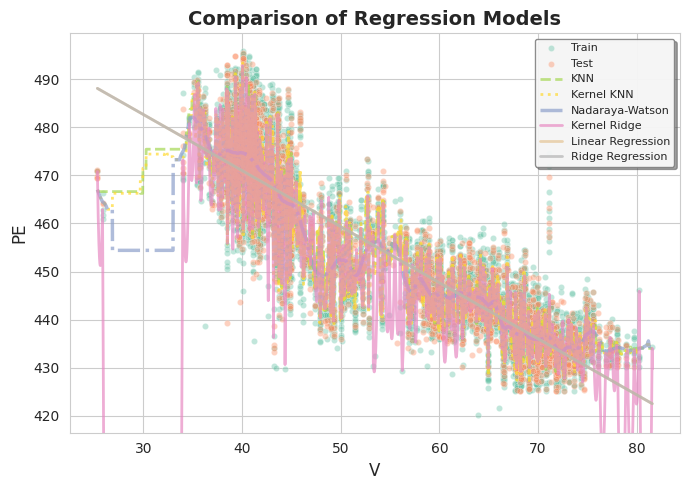

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(7, 5))

sns.set_style("whitegrid")

# Use a color palette
colors = sns.color_palette("Set2", 8)

# Scatterplots for train and test
sns.scatterplot(x=X_train.flatten(), y=y_train, alpha=0.4, label='Train', 
                color=colors[0], s=20)
sns.scatterplot(x=X_test.flatten(), y=y_test, alpha=0.4, label='Test', 
                color=colors[1], s=20)

# All predicted lines
plt.plot(X_line, y_line_knn, color=colors[4], linewidth=2, alpha=0.7, 
         linestyle='--', label='KNN')
plt.plot(X_line, y_line_kernel_knn, color=colors[5], linewidth=2, alpha=0.7, 
         linestyle=':', label='Kernel KNN')
plt.plot(X_line, y_line_nw, color=colors[2], linewidth=2.5, alpha=0.7, 
         linestyle='-.', label='Nadaraya-Watson')
plt.plot(X_line, y_line_kernel_ridge, color=colors[3], linewidth=2, alpha=0.7, 
         linestyle='-', label='Kernel Ridge')
plt.plot(X_line, y_line_slr, color=colors[6], linewidth=2, alpha=0.7, 
         label='Linear Regression')
plt.plot(X_line, y_line_ridge, color=colors[7], linewidth=2, alpha=0.7, 
         label='Ridge Regression')

# Set y-axis limits (trunc)
y_min = min(y_train.min(), y_test.min())
y_max = max(y_train.max(), y_test.max())
y_padding = (y_max - y_min) * 0.05
plt.ylim(y_min - y_padding, y_max + y_padding)

plt.xlabel('V', fontsize=12)
plt.ylabel('PE', fontsize=12)

# Legend
plt.legend(fontsize=8, loc='best', framealpha=0.9, edgecolor='gray', 
           fancybox=True, shadow=True)

plt.title('Comparison of Regression Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Images/all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()